In [2]:
from typing import TypedDict,Dict,List
from langgraph.graph import StateGraph,START,END

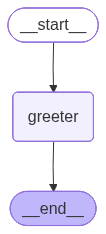

In [3]:
class AgentState(TypedDict):
    message:str 



def greeting_node(stae:AgentState)->AgentState:
    """Simple node that adds Greeting message to the state"""

    state["message"] = "Hey" + state["message"] + ", how is your day?"
    return state

graph=StateGraph(AgentState)
graph.add_node("greeter",greeting_node)

graph.add_edge(START,"greeter")
graph.add_edge("greeter",END)
graph.compile()

In [4]:
app=graph.compile()

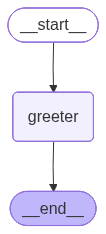

In [5]:
app

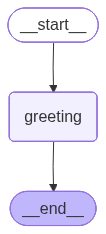

In [6]:
class StateAgent(TypedDict):
    message:str

def node_1(state:StateAgent)->StateAgent:
    name=input("enter_your name")
    state["message"] = "{name}" + state["message"] +"how was your day"

    return state

graph=StateGraph(StateAgent)
graph.add_node("greeting",node_1)
graph.add_edge(START,"greeting")
graph.add_edge("greeting",END)
graph.compile()

In [7]:
class AgentState(TypedDict):
    values:List[int]
    name:str
    result:str




In [8]:
def process_values(state:AgentState)->AgentState:
    """This function handles multiple differents inputs"""
    state["result"]=f"Hi there {state["name"]}! your sum = {sum(state["values"])} "

    return state

In [9]:
graph=StateGraph(AgentState)
graph.add_node("processor",process_values)
graph.add_edge(START,"processor")
graph.add_edge("processor",END)
app=graph.compile()

In [10]:
respons=app.invoke({"values":[1,2,3],"name":"Steve"})

In [11]:
print(respons)

{'values': [1, 2, 3], 'name': 'Steve', 'result': 'Hi there Steve! your sum = 6 '}


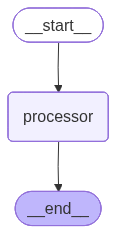

In [12]:
from typing import TypedDict,List,Dict
from langgraph.graph import StateGraph,START,END
from math import prod

class StateAgent(TypedDict):
    name:str
    values:List[int]
    operation:str
    message:str

def process_values(state:StateAgent)->StateAgent:
    if state['operation']=="+":
        result=sum(state["values"])
    else:
        result=prod(state["values"])
    state["message"] = f"Hi {state['name']}, your answer is: {result}"

    return state

graph=StateGraph(StateAgent)
graph.add_node("processor",process_values)
graph.add_edge(START,"processor")
graph.add_edge("processor",END)
app=graph.compile()
app
    

In [13]:
input_data = {
    "name": "Jack Sparrow",
    "values": [1, 2, 3, 4],
    "operation": "*"
}

result = app.invoke(input_data)

print(result["message"])

Hi Jack Sparrow, your answer is: 24


# Graph 3


In [14]:
from typing import TypedDict,Dict,List
from langgraph.graph import StateGraph,START,END


In [15]:
class AgentState(TypedDict):
    name:str
    age:int
    final:str

def first_node(state:AgentState)->AgentState:
    """This is the first node of our sequence"""
    state["final"]=f"hey there {state["name"]}"

    return state

def second_node(state:AgentState)->AgentState:
    """this is the second node of our sequence"""
    state["final"]=state["final"] + f" you are {state["age"]} years old"

    return state

graph=StateGraph(AgentState)
graph.add_node("first_node",first_node)
graph.add_node("second_node",second_node)
graph.add_edge(START,"first_node")
graph.add_edge("first_node","second_node")
graph.add_edge("second_node",END)

app=graph.compile()

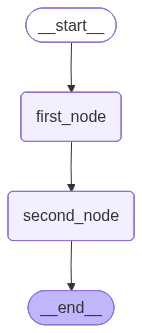

In [16]:
app

In [17]:
res=app.invoke({"name":"sami","age":20})
res

{'name': 'sami', 'age': 20, 'final': 'hey there sami you are 20 years old'}

# Graph-4

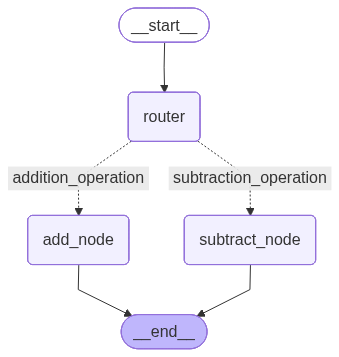

In [18]:
from typing import TypedDict,Dict,List
from langgraph.graph import StateGraph,START,END


class AgentState(TypedDict):
    number1:int
    operation:str
    number2:int
    finalNumber:int

def adder(state:AgentState)->AgentState:
    """this is the node that add the two numbers"""
    state["finalNumber"]=state["number1"]+state["number2"]

    return state

def subtractor(state:AgentState)->AgentState:
    """this is the node that sumtract the two numbers"""
    state["finalNumber"]=state["number1"]- state["number2"]

    return state

def decide_next_node(state:AgentState)->AgentState:
    """this node will select the next node of the graph"""
    if state["operator"]=="+":
        return "addition_operation"
    elif state["opeartion"]=="-":
        return "subtraction_operation"
    



graph=StateGraph(AgentState)
graph.add_node("add_node",adder)
graph.add_node("subtract_node",subtractor)
graph.add_node("router",lambda state:state)

graph.add_edge(START,"router")


graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
    "addition_operation":"add_node",
    "subtraction_operation":"subtract_node"
    }
)

graph.add_edge("add_node",END)
graph.add_edge("subtract_node",END)

app=graph.compile()
app

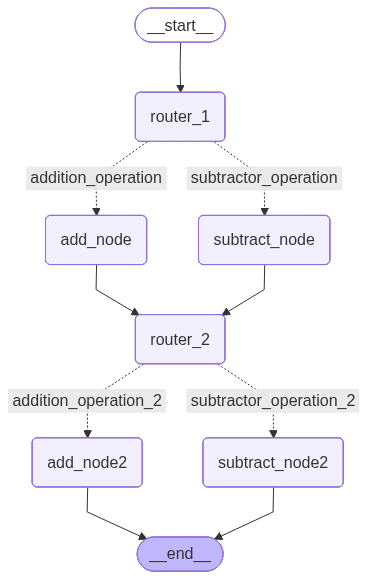

In [19]:
class AgentState(TypedDict):
    number1:int
    number2:int
    operation_1:str
    number3:int
    number4:int
    operation_2:str
    final_number1:int
    final_number2:int

def adder_1(state:AgentState)->AgentState:
    """this is the first node of sequence which will add two number"""
    state['final_number1'] = state["number1"]+state["number2"]
    return state

def sub_1(state:AgentState)->AgentState:
    """this is the first node of sequence which will add two number"""
    state['final_number1'] = state["number1"] - state["number2"]
    return state

def router_1(state:AgentState)->AgentState:
    if state["operation_1"]=="+":
        return "addition_operation"
    elif state["operation_1"]=="-":
        return "subtractor_operation_2"
    

def adder_2(state:AgentState)->AgentState:
    """this is the first node of sequence which will add two number"""
    state['final_number2'] = state["number3"]+state["number4"]
    return state

def sub_2(state:AgentState)->AgentState:
    """this is the first node of sequence which will add two number"""
    state['final_number2'] = state["number3"] - state["number4"]
    return state

def router_2(state:AgentState)->AgentState:
    if state["operation_2"]=="+":
        return "addition_operation_2"
    elif state["operation_2"]=="-":
        return "subtractor_operation_2"
    


graph = StateGraph(AgentState)

# Register nodes with clear names
graph.add_node("router_1", lambda state: state)
graph.add_node("add_node", adder_1)
graph.add_node("subtract_node", sub_1)
graph.add_node("router_2", lambda state: state)
graph.add_node("add_node2", adder_2)
graph.add_node("subtract_node2", sub_2)

# Start → router_1
graph.add_edge(START, "router_1")

# router_1 conditionally goes to add or subtract (operation 1)
graph.add_conditional_edges(
    "router_1",
    router_1,
    {
        "addition_operation": "add_node",       # fix: match what router_1 returns
        "subtractor_operation": "subtract_node"
    }
)

graph.add_edge("add_node","router_2")
graph.add_edge("subtract_node","router_2")


graph.add_conditional_edges(
    "router_2",
    router_2,
    {
        "addition_operation_2": "add_node2",
        "subtractor_operation_2": "subtract_node2"
    }
)



# After second operation, both paths lead to END
graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

app


# Graph 5

# Looping Graph

## Objectives:

1. Implement looping logic to route the flow of data back to the nodes

2. create  a single conditional edge to handle desicion-making and control graph flow

## Main Goal:

Coding up Looping Agent

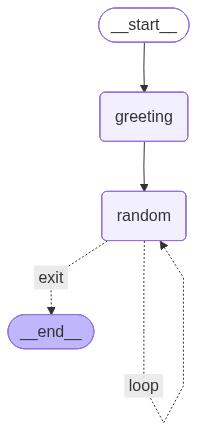

In [20]:
import random

class AgentState(TypedDict):
    name:str
    number:List[int]

    counter:int

def greeting_node(state:AgentState)->AgentState:
    """Greeting Node which says hi to the person """
    state['name']=f"Hi there, {state["name"]}"
    state["counter"]=0

    return state

def random_node(state:AgentState)->AgentState:
    """Generates a random number from 0 to 10 """
    state["number"].append(random.randint(0,10))
    state['counter'] +=1
    return state


def should_continue(state:AgentState)->AgentState:
    """Function to decide what to do next"""
    if state["counter"]<4:
        print("Entering the loop",state['counter'])
        return "loop"
    else :
        return "exit"
    


graph=StateGraph(AgentState)
graph.add_node("greeting",greeting_node)
graph.add_node("random",random_node)
graph.add_edge("greeting","random")
graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop":"random",
        "exit":END
    }
)

graph.set_entry_point("greeting")
app=graph.compile()
app
